#### Unsupervised Learning with K-Means Clustering.

Sample data shape: (30, 3)
First 5 samples:
 [[5.64901425 3.17234714 1.92953771]
 [5.95690896 3.15316933 1.75317261]
 [5.97376384 3.35348695 1.70610512]
 [5.66276801 3.10731646 1.70685405]
 [5.57258868 2.81734395 1.45501643]]
First 5 varieties: ['Variety_A', 'Variety_A', 'Variety_A', 'Variety_A', 'Variety_A']


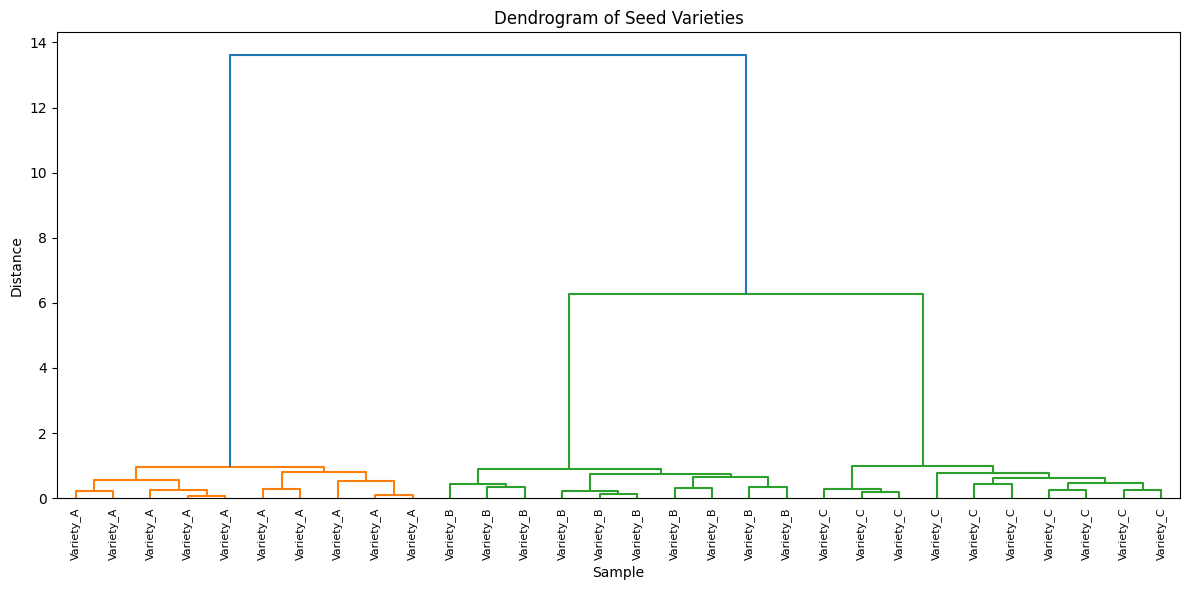


Confusion Matrix (Clusters vs Actual Varieties):
varieties  Variety_A  Variety_B  Variety_C
labels                                    
1                 10          0          0
2                  0         10         10

Adjusted Rand Index: 0.554


In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# Create sample dataset (wheat seed varieties)
np.random.seed(42)
n_samples = 30

# Create 3 distinct varieties of seeds
varieties = []
samples = []

# Variety A (0-9)
for i in range(10):
    varieties.append('Variety_A')
    samples.append([5.5 + np.random.randn()*0.3, 
                    3.2 + np.random.randn()*0.2,
                    1.8 + np.random.randn()*0.2])

# Variety B (10-19)
for i in range(10):
    varieties.append('Variety_B')
    samples.append([6.2 + np.random.randn()*0.3,
                    3.0 + np.random.randn()*0.2,
                    4.5 + np.random.randn()*0.2])

# Variety C (20-29)
for i in range(10):
    varieties.append('Variety_C')
    samples.append([7.0 + np.random.randn()*0.3,
                    3.5 + np.random.randn()*0.2,
                    6.2 + np.random.randn()*0.2])

# Convert to numpy array
samples = np.array(samples)

print("Sample data shape:", samples.shape)
print("First 5 samples:\n", samples[:5])
print("First 5 varieties:", varieties[:5])

# Calculate linkage
mergings = linkage(samples, method='ward')

# Plot dendrogram to see the clusters
plt.figure(figsize=(12, 6))
dendrogram(mergings, labels=varieties, leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrogram of Seed Varieties')
plt.xlabel('Sample')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Use fcluster to extract labels 
labels = fcluster(mergings, 7, criterion='distance')

# Create a DataFrame with labels and varieties as columns: df
df = pd.DataFrame({'labels': labels, 'varieties': varieties})

# Create crosstab 
ct = pd.crosstab(df['labels'], df['varieties'])

# Display ct
print("\nConfusion Matrix (Clusters vs Actual Varieties):")
print(ct)

# Calculate clustering accuracy
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(varieties, labels)
print(f"\nAdjusted Rand Index: {ari:.3f}")
